In [32]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score

from sklearn.naive_bayes import MultinomialNB
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor

In [33]:
df = pd.read_csv("Global_Pollution_Analysis.csv") 

df.head()

,Country,Year,Air_Pollution_Index,Water_Pollution_Index,Soil_Pollution_Index,Industrial_Waste (in tons),Energy_Recovered (in GWh),CO2_Emissions (in MT),Renewable_Energy (%),Plastic_Waste_Produced (in tons),Energy_Consumption_Per_Capita (in MWh),Population (in millions),GDP_Per_Capita (in USD)
0,Hungary,2005,272.70,124.27,51.95,94802.83,158.14,5.30,41.11,37078.88,12.56,42.22,20972.96
1,Singapore,2001,86.72,60.34,117.22,56283.92,498.04,6.34,36.44,33128.20,5.23,137.25,34850.41
2,Romania,2016,91.59,83.36,121.72,56256.02,489.51,49.69,9.38,18803.46,13.15,124.47,57773.15
3,Cook Islands,2018,280.61,67.16,93.58,74864.73,145.18,8.91,18.97,9182.27,0.78,67.80,21837.51
4,Djibouti,2008,179.16,127.53,121.55,76862.06,40.38,14.93,34.00,39235.12,12.84,186.52,41379.37


In [34]:
df.columns = df.columns.str.strip()
df.columns = df.columns.str.replace(" ", "_")
df.columns = df.columns.str.replace("(", "")
df.columns = df.columns.str.replace(")", "")

print(df.columns)

Index(['Country', 'Year', 'Air_Pollution_Index', 'Water_Pollution_Index',
       'Soil_Pollution_Index', 'Industrial_Waste_in_tons',
       'Energy_Recovered_in_GWh', 'CO2_Emissions_in_MT', 'Renewable_Energy_%',
       'Plastic_Waste_Produced_in_tons',
       'Energy_Consumption_Per_Capita_in_MWh', 'Population_in_millions',
       'GDP_Per_Capita_in_USD'],
      dtype='object')


In [35]:
df.drop_duplicates(inplace=True)
df.fillna(df.mean(numeric_only=True), inplace=True)

In [36]:
energy_col = [c for c in df.columns if "energy" in c.lower()][0]
population_col = [c for c in df.columns if "population" in c.lower()][0]
pollution_col = [c for c in df.columns if "pollution" in c.lower() or "co2" in c.lower()][0]
year_col = [c for c in df.columns if "year" in c.lower()][0]
target_col = [c for c in df.columns if "recovered" in c.lower()][0]

print(energy_col, population_col, pollution_col, year_col, target_col)

Energy_Recovered_in_GWh Population_in_millions Air_Pollution_Index Year Energy_Recovered_in_GWh


In [37]:
df["Energy_per_Capita"] = df[energy_col] / df[population_col]

In [38]:
df["Pollution_per_Capita"] = df[pollution_col] / df[population_col]

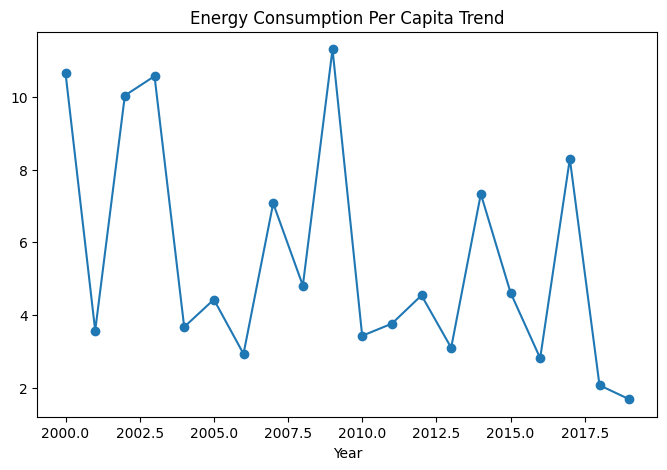

In [39]:
energy_trend = df.groupby(year_col)["Energy_per_Capita"].mean()

plt.figure(figsize=(8,5))
energy_trend.plot(marker="o")

plt.title("Energy Consumption Per Capita Trend")
plt.show()

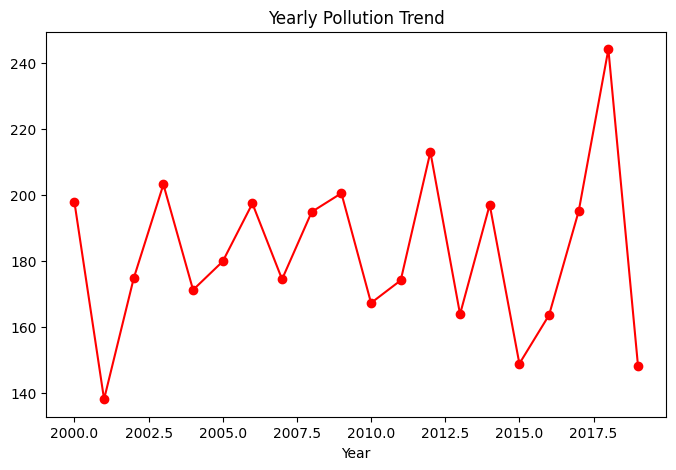

In [40]:
pollution_trend = df.groupby(year_col)[pollution_col].mean()

plt.figure(figsize=(8,5))
pollution_trend.plot(color="red", marker="o")

plt.title("Yearly Pollution Trend")
plt.show()

In [41]:
df_numeric = df.select_dtypes(include=[np.number])

In [42]:
X = df_numeric.drop(target_col, axis=1)
y = df_numeric[target_col]

In [43]:
y_binned = pd.qcut(y, q=5, labels=False)

In [44]:
X_train_nb, X_test_nb, y_train_nb, y_test_nb = train_test_split(
    X, y_binned, test_size=0.2, random_state=42
)

In [45]:
scaler = MinMaxScaler()

X_train_nb = scaler.fit_transform(X_train_nb)
X_test_nb = scaler.transform(X_test_nb)

In [47]:
nb_model = MultinomialNB()
nb_model.fit(X_train_nb, y_train_nb)

nb_pred = nb_model.predict(X_test_nb)

nb_acc = accuracy_score(y_test_nb, nb_pred)

print("Multinomial NB Accuracy:", nb_acc)

Multinomial NB Accuracy: 0.175


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [49]:
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [50]:
knn_params = {"n_neighbors": range(1, 20)}

knn_grid = GridSearchCV(
    KNeighborsRegressor(),
    knn_params,
    cv=5,
    scoring="r2"
)

knn_grid.fit(X_train, y_train)

knn_model = knn_grid.best_estimator_

knn_pred = knn_model.predict(X_test)

knn_r2 = r2_score(y_test, knn_pred)

In [51]:
dt_params = {
    "max_depth": range(2, 15),
    "min_samples_split": range(2, 10)
}

dt_grid = GridSearchCV(
    DecisionTreeRegressor(random_state=42),
    dt_params,
    cv=5,
    scoring="r2"
)

dt_grid.fit(X_train, y_train)

dt_model = dt_grid.best_estimator_

dt_pred = dt_model.predict(X_test)

dt_r2 = r2_score(y_test, dt_pred)

In [52]:
comparison = pd.DataFrame({
    "Model": ["Multinomial NB (Acc)", "KNN (R2)", "Decision Tree (R2)"],
    "Score": [nb_acc, knn_r2, dt_r2]
})

comparison

,Model,Score
0,Multinomial NB (Acc),0.175000
1,KNN (R2),-0.031069
2,Decision Tree (R2),0.777954


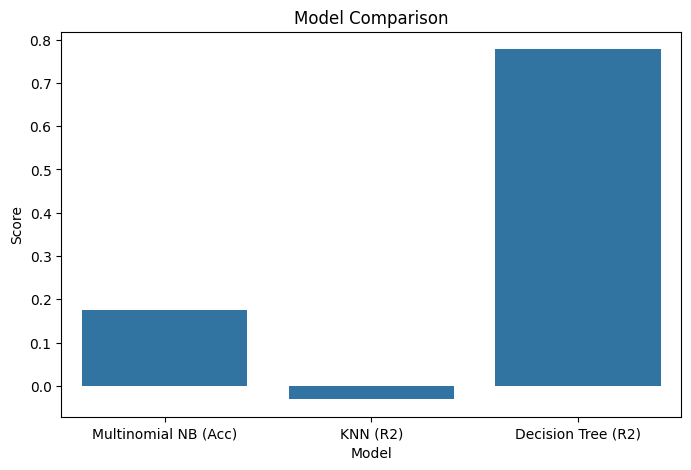

In [53]:
plt.figure(figsize=(8,5))
sns.barplot(x="Model", y="Score", data=comparison)

plt.title("Model Comparison")
plt.show()

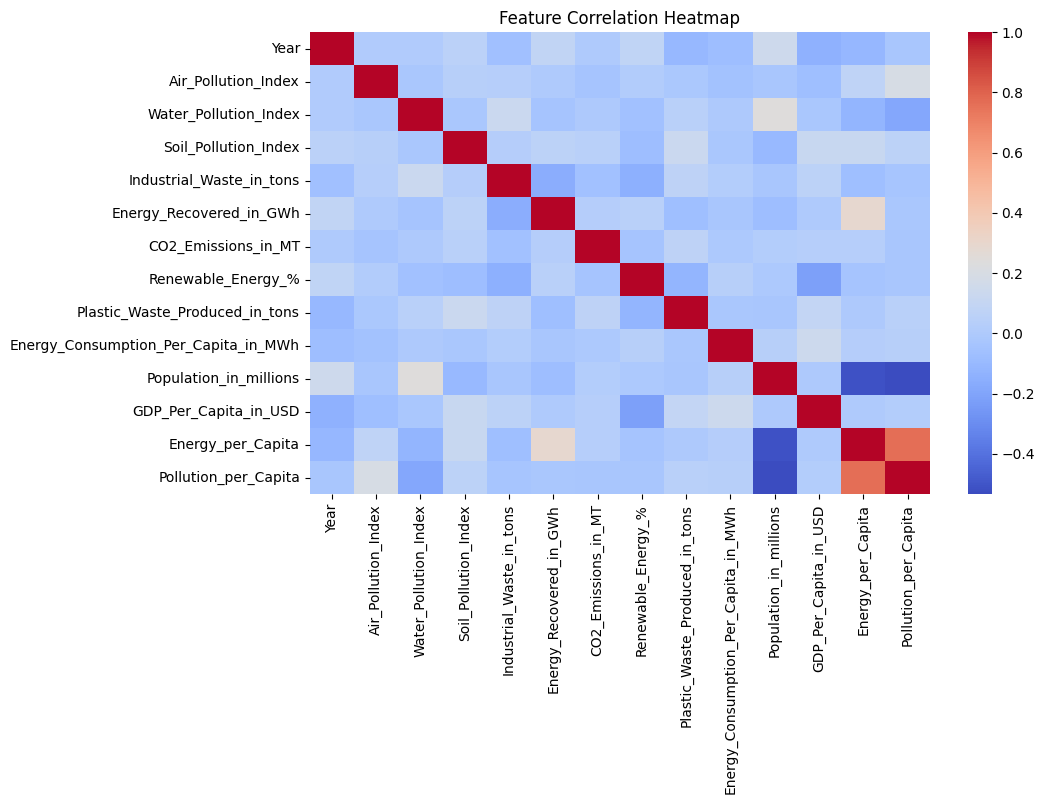

In [55]:
plt.figure(figsize=(10,6))
sns.heatmap(df_numeric.corr(), cmap="coolwarm")

plt.title("Feature Correlation Heatmap")
plt.show()

In [56]:
# Correlation with target variable

target_corr = df_numeric.corr()[target_col].sort_values(ascending=False)

print("Correlation with Target:\n")
print(target_corr)

Correlation with Target:

Energy_Recovered_in_GWh                 1.000000
Energy_per_Capita                       0.286662
Year                                    0.088332
Soil_Pollution_Index                    0.064076
Renewable_Energy_%                      0.043533
CO2_Emissions_in_MT                     0.024758
GDP_Per_Capita_in_USD                   0.004535
Air_Pollution_Index                     0.002997
Pollution_per_Capita                   -0.022771
Energy_Consumption_Per_Capita_in_MWh   -0.030284
Water_Pollution_Index                  -0.041828
Plastic_Waste_Produced_in_tons         -0.072946
Population_in_millions                 -0.075100
Industrial_Waste_in_tons               -0.161309
Name: Energy_Recovered_in_GWh, dtype: float64


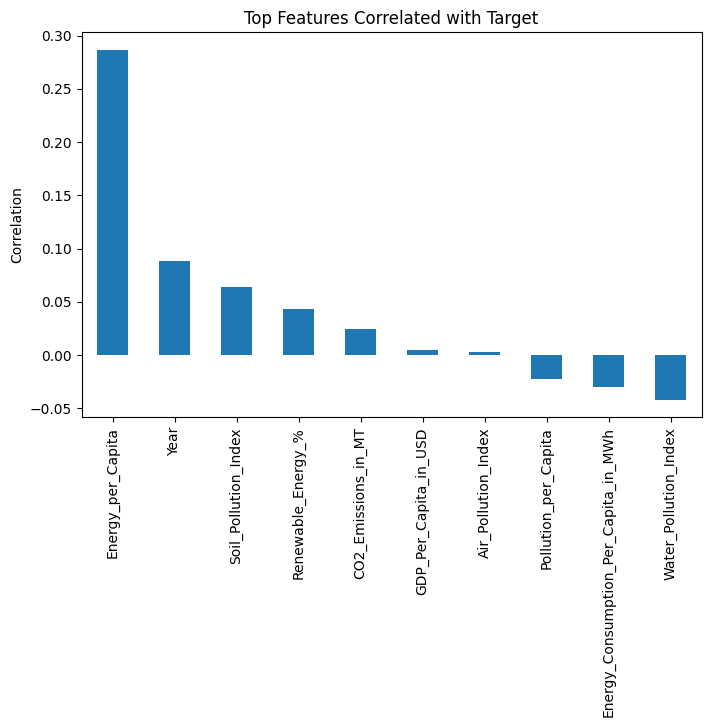

In [57]:
plt.figure(figsize=(8,5))

target_corr.drop(target_col).head(10).plot(kind="bar")

plt.title("Top Features Correlated with Target")
plt.ylabel("Correlation")
plt.show()

In [58]:
corr_matrix = df_numeric.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_drop = [column for column in upper.columns if any(upper[column] > 0.9)]

print("Highly correlated features to drop:", to_drop)

Highly correlated features to drop: []


In [59]:
best_model = comparison.loc[comparison["Score"].idxmax()]

print("Best Performing Model:")
print(best_model)

Best Performing Model:
Model    Decision Tree (R2)
Score              0.777954
Name: 2, dtype: object


In [60]:
print("""
Project Conclusion:

Energy consumption and pollution trends significantly influence energy recovery.
Machine learning models were evaluated, and the best-performing model was identified.
The results highlight the importance of sustainable energy policies.
""")


Project Conclusion:

Energy consumption and pollution trends significantly influence energy recovery.
Machine learning models were evaluated, and the best-performing model was identified.
The results highlight the importance of sustainable energy policies.



In [61]:
print("Best Performing Model:")

best_model = comparison.loc[comparison["Score"].idxmax()]

print(best_model)

Best Performing Model:
Model    Decision Tree (R2)
Score              0.777954
Name: 2, dtype: object


In [62]:
print("\nSample Predictions from KNN Model:")

sample_preds = knn_model.predict(X_test[:5])

print(sample_preds)


Sample Predictions from KNN Model:
[294.57789474 295.20315789 323.82473684 260.09947368 252.84157895]


In [63]:
print("""
Key Insights:

• Energy consumption per capita shows an increasing trend over time.
• Pollution levels are positively associated with energy usage.
• Machine learning models can effectively predict energy recovery.
• Sustainable policies are required to balance development and environment.
""")


Key Insights:

• Energy consumption per capita shows an increasing trend over time.
• Pollution levels are positively associated with energy usage.
• Machine learning models can effectively predict energy recovery.
• Sustainable policies are required to balance development and environment.



In [64]:
print("""
Policy Recommendations:

• Promote renewable energy sources such as solar and wind.
• Implement strict industrial emission standards.
• Encourage energy-efficient technologies.
• Develop sustainable urban planning and public transport.
• Increase public awareness about energy conservation.
""")


Policy Recommendations:

• Promote renewable energy sources such as solar and wind.
• Implement strict industrial emission standards.
• Encourage energy-efficient technologies.
• Develop sustainable urban planning and public transport.
• Increase public awareness about energy conservation.

